# CNN Baseline Comparison

## Objective

Compare CNN Baseline V1 and CNN Baseline V2 experiments.

The goal is to determine whether architectural improvements and regularization
provided meaningful improvements before moving to transfer learning.

We compare:

- Training dynamics
- Validation performance
- Test metrics
- Confusion matrices
- Error rates
- Generalization behavior

## IMPORTS

In [16]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

## LOAD EXPERIMENT ARTIFACT

In [17]:
PROJECT_ROOT = Path("../")


V1_DIR = (
    PROJECT_ROOT
    /
    "experiments"
    /
    "cnn_baseline_v1"
)


V2_DIR = (
    PROJECT_ROOT
    /
    "experiments"
    /
    "cnn_baseline_v2"
)


print(V1_DIR)
print(V2_DIR)

../experiments/cnn_baseline_v1
../experiments/cnn_baseline_v2


## HELPER LOADER FUNCTIONS

In [18]:
def load_json(path):

    with open(path) as f:
        return json.load(f)



def load_experiment(exp_dir):

    history = load_json(
        exp_dir /
        "logs" /
        "training_history.json"
    )


    metrics = load_json(
        exp_dir /
        "results" /
        "metrics.json"
    )


    confusion_matrix = np.load(
        exp_dir /
        "results" /
        "confusion_matrix.npy"
    )


    predictions = pd.read_csv(
        exp_dir /
        "results" /
        "predictions.csv"
    )


    return {
        "history": history,
        "metrics": metrics,
        "confusion_matrix": confusion_matrix,
        "predictions": predictions,
    }

## LOAD EXPERIMENTS

In [19]:
v1 = load_experiment(V1_DIR)

v2 = load_experiment(V2_DIR)


print("V1 loaded ✓")
print("V2 loaded ✓")

V1 loaded ✓
V2 loaded ✓


## 1. Test Performance Comparison

Compare final evaluation metrics.

In [20]:
comparison = pd.DataFrame(
    {
        "CNN Baseline V1": v1["metrics"],
        "CNN Baseline V2": v2["metrics"],
    }
)


comparison

,CNN Baseline V1,CNN Baseline V2
accuracy,0.811162,0.964067
precision,0.827275,0.964289
recall,0.812054,0.967973
f1,0.811500,0.965532
loss,0.528271,0.127973


## IMPROVEMENT CALCULATION

In [21]:
improvement = pd.DataFrame(
    {
        "Absolute Improvement":
        comparison["CNN Baseline V2"]
        -
        comparison["CNN Baseline V1"],


        "Relative Improvement (%)":
        (
            (
                comparison["CNN Baseline V2"]
                -
                comparison["CNN Baseline V1"]
            )
            /
            comparison["CNN Baseline V1"]
        )
        *
        100
    }
)


improvement

,Absolute Improvement,Relative Improvement (%)
accuracy,0.152905,18.850141
precision,0.137014,16.562115
recall,0.155920,19.200661
f1,0.154032,18.981163
loss,-0.400298,-75.775123


## 2. Training and Validation Curves

Compare convergence behavior.

Questions:

- Which model learns faster?
- Which model is more stable?
- Is there evidence of overfitting?

## TRAINING LOSS

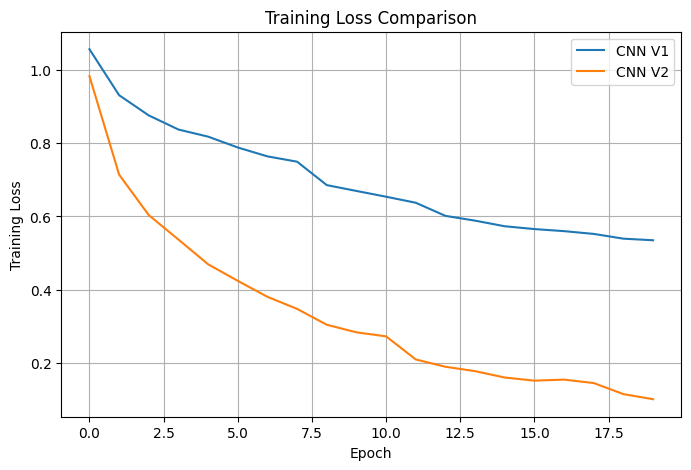

In [22]:
plt.figure(figsize=(8,5))


plt.plot(
    v1["history"]["train_loss"],
    label="CNN V1"
)


plt.plot(
    v2["history"]["train_loss"],
    label="CNN V2"
)


plt.xlabel("Epoch")
plt.ylabel("Training Loss")

plt.title(
    "Training Loss Comparison"
)

plt.legend()

plt.grid()

plt.show()

## VALIDATION LOSS

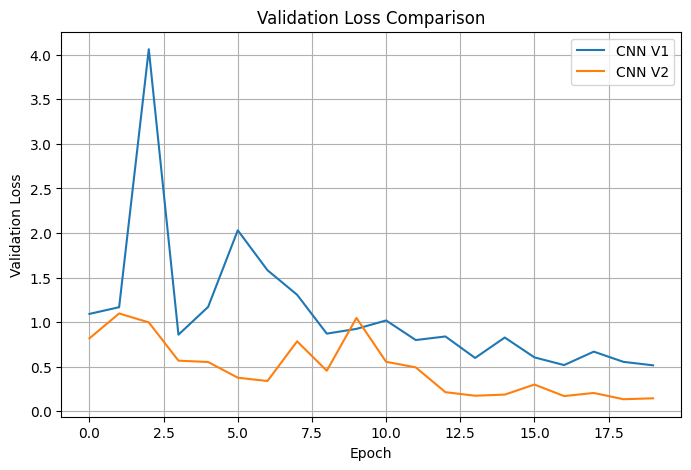

In [23]:
plt.figure(figsize=(8,5))


plt.plot(
    v1["history"]["val_loss"],
    label="CNN V1"
)


plt.plot(
    v2["history"]["val_loss"],
    label="CNN V2"
)


plt.xlabel("Epoch")
plt.ylabel("Validation Loss")

plt.title(
    "Validation Loss Comparison"
)


plt.legend()

plt.grid()

plt.show()

## TRAINING ACCURACY

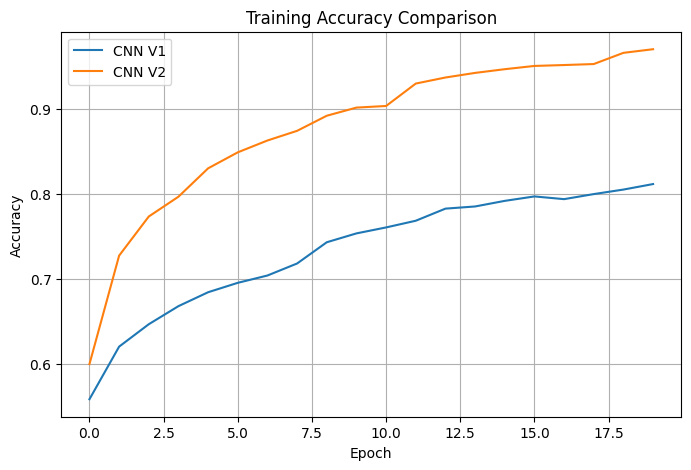

In [24]:
plt.figure(figsize=(8,5))


plt.plot(
    v1["history"]["train_accuracy"],
    label="CNN V1"
)


plt.plot(
    v2["history"]["train_accuracy"],
    label="CNN V2"
)


plt.xlabel("Epoch")
plt.ylabel("Accuracy")


plt.title(
    "Training Accuracy Comparison"
)


plt.legend()

plt.grid()

plt.show()

## VALIDATION ACCURACY

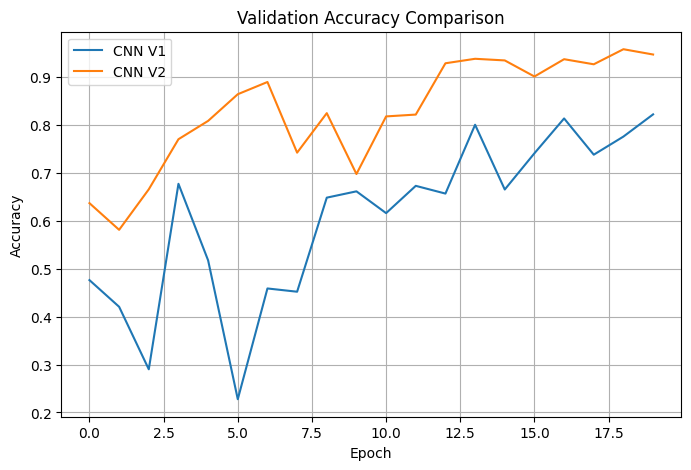

In [25]:
plt.figure(figsize=(8,5))


plt.plot(
    v1["history"]["val_accuracy"],
    label="CNN V1"
)


plt.plot(
    v2["history"]["val_accuracy"],
    label="CNN V2"
)


plt.xlabel("Epoch")
plt.ylabel("Accuracy")


plt.title(
    "Validation Accuracy Comparison"
)


plt.legend()

plt.grid()

plt.show()

## 3. Confusion Matrix Comparison

Normalized confusion matrices show class-level recall.

This helps identify:

- dominant classes
- difficult classes
- systematic confusion

## V1 confusion matrix

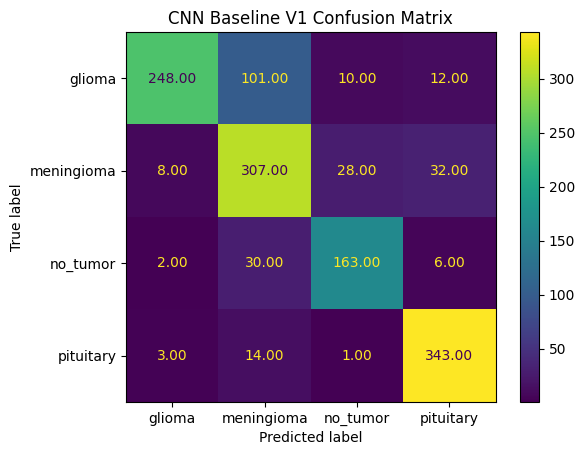

In [26]:
class_names = [
    "glioma",
    "meningioma",
    "no_tumor",
    "pituitary"
]


disp = ConfusionMatrixDisplay(
    confusion_matrix=v1["confusion_matrix"],
    display_labels=class_names
)


disp.plot(
    values_format=".2f"
)


plt.title(
    "CNN Baseline V1 Confusion Matrix"
)

plt.show()

## V2 confusion matrix

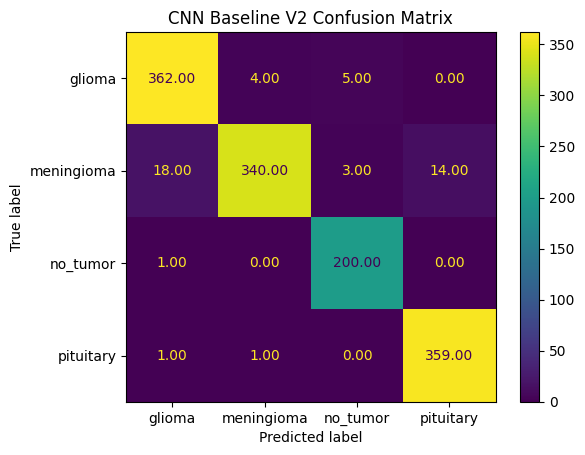

In [27]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=v2["confusion_matrix"],
    display_labels=class_names
)


disp.plot(
    values_format=".2f"
)


plt.title(
    "CNN Baseline V2 Confusion Matrix"
)

plt.show()

## 4. Error Rate Comparison

In [28]:
v1_errors = (
    v1["predictions"]["true_label"]
    !=
    v1["predictions"]["predicted_label"]
).sum()



v2_errors = (
    v2["predictions"]["true_label"]
    !=
    v2["predictions"]["predicted_label"]
).sum()



error_comparison = pd.DataFrame(
    {
        "Model":
        [
            "CNN V1",
            "CNN V2"
        ],

        "Errors":
        [
            v1_errors,
            v2_errors
        ]
    }
)


error_comparison

,Model,Errors
0,CNN V1,247
1,CNN V2,47


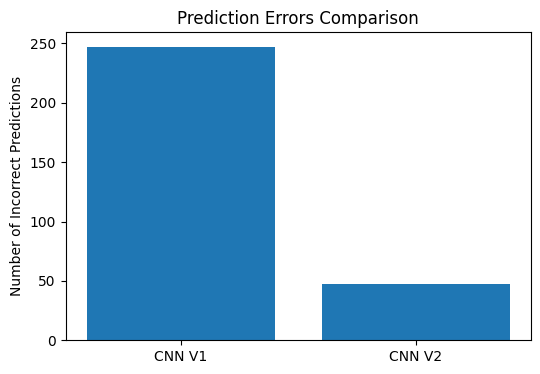

In [29]:
plt.figure(figsize=(6,4))


plt.bar(
    error_comparison["Model"],
    error_comparison["Errors"]
)


plt.title(
    "Prediction Errors Comparison"
)


plt.ylabel(
    "Number of Incorrect Predictions"
)


plt.show()

## 5. Prediction Distribution Analysis

In [30]:
pred_distribution = pd.DataFrame(
    {
        "CNN V1":
        v1["predictions"]["predicted_label"].value_counts(),

        "CNN V2":
        v2["predictions"]["predicted_label"].value_counts(),
    }
)


pred_distribution

,CNN V1,CNN V2
predicted_label,,
0,261,382
1,452,345
2,202,208
3,393,373


# CONCLUSION

CNN Baseline V2 establishes a strong custom CNN benchmark.

The model achieves:

Accuracy: 96.4%
Macro F1: 96.5%

Compared with the initial baseline:

- accuracy improved by 18.8%
- classification errors reduced by 81%
- loss decreased by 75%

The improvement demonstrates that increasing convolutional depth,
feature capacity, and applying dropout significantly improves MRI
classification performance.

This baseline will serve as the reference point for evaluating
transfer learning approaches.